<a href="https://colab.research.google.com/github/demisewt21/CodeAlpha_CreditScoringModel/blob/main/Credit_Scoring_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

# ✅ NEW WORKING LINK for Credit Risk Dataset
url = "https://raw.githubusercontent.com/sangramdedge/Credit-Risk-Analysis-Prediction-Dashboard/main/credit_risk_dataset.csv"
df = pd.read_csv(url)

print("✅ Dataset loaded successfully!")
print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nTarget column (loan_status):")
print(df['loan_status'].value_counts())
print("\nColumns in the dataset:")
print(df.columns.tolist())

✅ Dataset loaded successfully!
Shape: (32581, 12)

First 5 rows:
   person_age  person_income person_home_ownership  person_emp_length  \
0          22          59000                  RENT              123.0   
1          21           9600                   OWN                5.0   
2          25           9600              MORTGAGE                1.0   
3          23          65500                  RENT                4.0   
4          24          54400                  RENT                8.0   

  loan_intent loan_grade  loan_amnt  loan_int_rate  loan_status  \
0    PERSONAL          D      35000          16.02            1   
1   EDUCATION          B       1000          11.14            0   
2     MEDICAL          C       5500          12.87            1   
3     MEDICAL          C      35000          15.23            1   
4     MEDICAL          C      35000          14.27            1   

   loan_percent_income cb_person_default_on_file  cb_person_cred_hist_length  
0             

=== Basic Information ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB
None


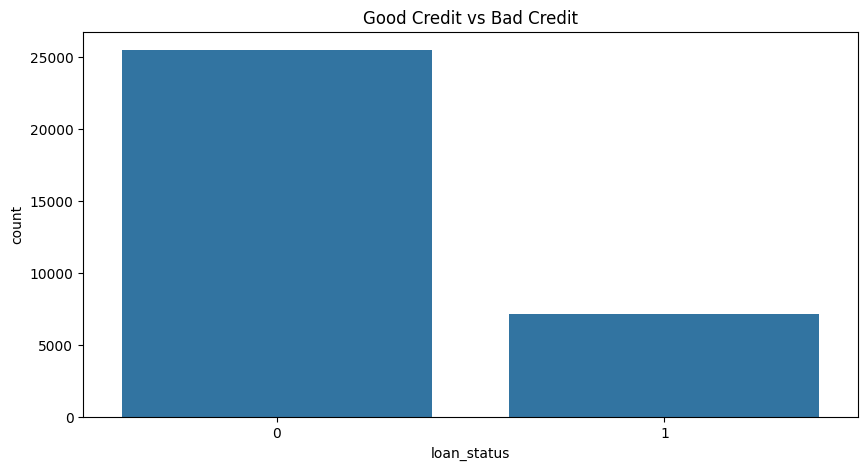

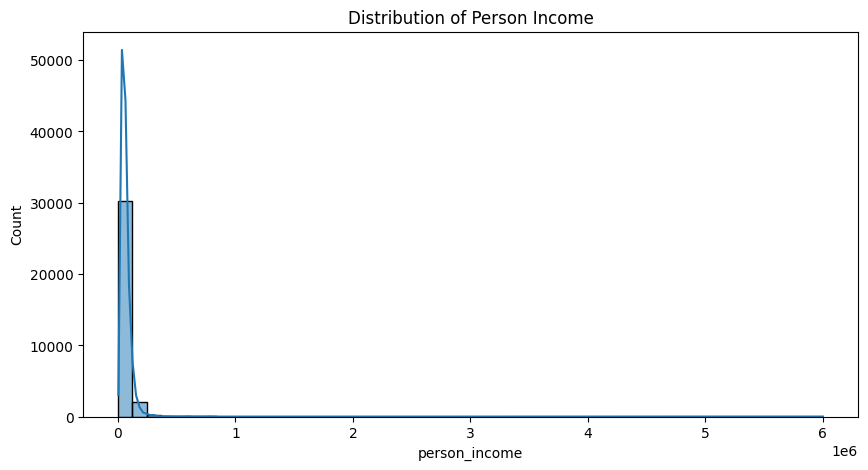


✅ EDA completed! You can see the charts now.


In [ ]:
# Cell 2: Explore the Data (EDA)

print("=== Basic Information ===")
print(df.info())

print("\n=== Missing Values ===")
print(df.isnull().sum())

print("\n=== Target Distribution (Credit Risk) ===")
print(df['loan_status'].value_counts())
print("0 = Good Credit (Loan Paid) | 1 = Bad Credit (Default)")

# Simple plots
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
sns.countplot(x='loan_status', data=df)
plt.title("Good Credit vs Bad Credit")
plt.show()

plt.figure(figsize=(10,5))
sns.histplot(df['person_income'], bins=50, kde=True)
plt.title("Distribution of Person Income")
plt.show()

print("\n✅ EDA completed! You can see the charts now.")

In [ ]:
# Cell 3: Data Preprocessing

# 1. Handle missing values
df['person_emp_length'] = df['person_emp_length'].fillna(df['person_emp_length'].median())
df['loan_int_rate'] = df['loan_int_rate'].fillna(df['loan_int_rate'].median())

print("✅ Missing values filled!")

# 2. Encode categorical columns
from sklearn.preprocessing import LabelEncoder

categorical_cols = ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']
label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

print("✅ Categorical columns encoded!")

# 3. Separate features (X) and target (y)
X = df.drop('loan_status', axis=1)
y = df['loan_status']

# 4. Split into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Scale the numerical features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("✅ Data preprocessing completed!")
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

✅ Missing values filled!
✅ Categorical columns encoded!
✅ Data preprocessing completed!
Training samples: 26064
Testing samples: 6517


In [ ]:
# Cell 4: Train Models + Evaluation

# Train 3 models as required in the task
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None

    acc = accuracy_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_prob) if y_prob is not None else "N/A"

    print(f"\n🔥 {name}")
    print(f"Accuracy : {acc:.4f}")
    print(f"ROC-AUC  : {roc}")
    print(classification_report(y_test, y_pred))

    results[name] = acc

# Show the best model
best_model_name = max(results, key=results.get)
print(f"\n🏆 Best Model: {best_model_name} with Accuracy {results[best_model_name]:.4f}")

print("\n✅ All models trained successfully!")


🔥 Logistic Regression
Accuracy : 0.8372
ROC-AUC  : 0.8433564286727866
              precision    recall  f1-score   support

           0       0.86      0.95      0.90      5072
           1       0.72      0.44      0.55      1445

    accuracy                           0.84      6517
   macro avg       0.79      0.70      0.72      6517
weighted avg       0.83      0.84      0.82      6517


🔥 Decision Tree
Accuracy : 0.8857
ROC-AUC  : 0.8434176235905384
              precision    recall  f1-score   support

           0       0.93      0.92      0.93      5072
           1       0.73      0.77      0.75      1445

    accuracy                           0.89      6517
   macro avg       0.83      0.84      0.84      6517
weighted avg       0.89      0.89      0.89      6517


🔥 Random Forest
Accuracy : 0.9296
ROC-AUC  : 0.9349286536845207
              precision    recall  f1-score   support

           0       0.92      0.99      0.96      5072
           1       0.96      0.71   

In [ ]:
# Cell 5: Make a Prediction (11 features)

# Example new loan applicant
sample = [[25, 35000, 3, 3.0, 4, 1, 5000, 12.0, 0.14, 0, 3]]

# Convert to DataFrame with correct column names
sample_df = pd.DataFrame(sample, columns=X.columns)

# Scale the sample
sample_scaled = scaler.transform(sample_df)

# Use the best model
best_model = models[best_model_name]
prediction = best_model.predict(sample_scaled)[0]
probability = best_model.predict_proba(sample_scaled)[0][1]

print("🔍 Prediction for this new applicant:")
if prediction == 0:
    print("✅ Good Credit - Loan will be APPROVED")
else:
    print("❌ Bad Credit - Loan will be REJECTED")

print(f"Risk of Default: {probability*100:.2f}%")

# Show what each number means
print("\nSample Applicant Details:")
print("• Age                    :", sample[0][0])
print("• Income                 :", sample[0][1])
print("• Home Ownership         :", sample[0][2])
print("• Employment Length (yrs):", sample[0][3])
print("• Loan Intent            :", sample[0][4])
print("• Loan Grade             :", sample[0][5])
print("• Loan Amount            :", sample[0][6])
print("• Interest Rate          :", sample[0][7])
print("• Loan % of Income       :", sample[0][8])
print("• Default on File        :", sample[0][9])
print("• Credit History Length  :", sample[0][10])

🔍 Prediction for this new applicant:
✅ Good Credit - Loan will be APPROVED
Risk of Default: 11.00%

Sample Applicant Details:
• Age                    : 25
• Income                 : 35000
• Home Ownership         : 3
• Employment Length (yrs): 3.0
• Loan Intent            : 4
• Loan Grade             : 1
• Loan Amount            : 5000
• Interest Rate          : 12.0
• Loan % of Income       : 0.14
• Default on File        : 0
• Credit History Length  : 3
